# Double Deep Q Learning

It was shown that DQN suffers for overestimating action values under certain conditions. Double Deep Q-learning is a specific adaptation of DQN algorithms that was proven to reduce these overestimaes. 
Problem is that the DQN learns unreallisticly high action values, because it includes a maximization step over estimated action values, which tends to prefer overestimated to underestimated values. Overestimates are not a problem themselves, they won't affect the perfomance, if they are uniform, the problem appears when they are. 
To prevent this, Double Q-learning proposes to instead of having a single Q function, we have two - Q1 and Q2. In pratice we have to modidy the target by sticking arg max operator inside the Q2 function and taking the max over Q1 rather than Q2. Then wwe swap the roles of Q1 and Q2 to make sure that each Q function gets updated evenly. 

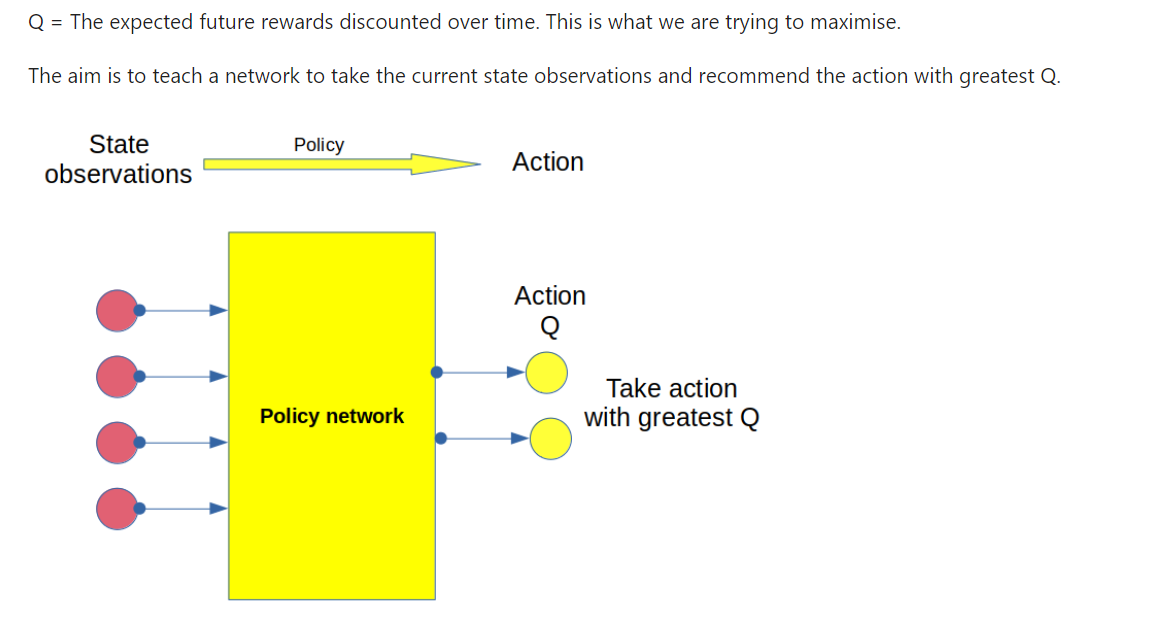

Paper: https://arxiv.org/abs/1509.06461

Source code: https://github.com/MichaelAllen1966/qambo

In [1]:
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.optim as optim

from Environment.simulator import *
from Environment.my_utils import *

from collections import deque

import warnings

warnings.filterwarnings("ignore")

In [2]:
# Replicate runs
TEST_EPISODES = 10

# SIM PARAMETERS
SLA = 0.5
VM_TYPE1 = 5
VM_TYPE2 = 3
VM_TYPE3 = 1
STEPS = 100
ALPHA = 0.5
BETA = 0.5

GAMMA = 0.99
# Learing rate for neural network
LEARNING_RATE = 0.003
# Maximum number of game steps (state, action, reward, next state) to keep
MEMORY_SIZE = 10000000
# Sample batch size for policy network update
BATCH_SIZE = 5
# Number of game steps to play before starting training (all random actions)
REPLAY_START_SIZE = 50000
# Number of steps between policy -> target network update
SYNC_TARGET_STEPS = 1000
# Exploration rate (epsilon) is probability of choosing a random action
EXPLORATION_MAX = 1.0
EXPLORATION_MIN = 0.05
# Reduction in epsilon with each game step
EXPLORATION_DECAY = 0.9999
# Training episodes
TRAINING_EPISODES = 50
# Save results
RESULTS_NAME = 'ddqn'

Define DQN (Deep Q Network) class

In [3]:
class DQN(nn.Module):
    """Deep Q Network. Udes for both policy (action) and target (Q) networks."""

    def __init__(self, observation_space, action_space):
        """Constructor method. Set up neural nets."""

        # nerurones per hidden layer = 2 * max of observations or actions
        neurons_per_layer = 2 * max(observation_space, action_space)

        # Set starting exploration rate
        self.exploration_rate = EXPLORATION_MAX

        # Set up action space (choice of possible actions)
        self.action_space = action_space

        super(DQN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(observation_space, neurons_per_layer),
            nn.ReLU(),
            nn.Linear(neurons_per_layer, neurons_per_layer),
            nn.ReLU(),
            nn.Linear(neurons_per_layer, neurons_per_layer),
            nn.ReLU(),
            nn.Linear(neurons_per_layer, action_space)
        )

    def act(self, state):
        """Act either randomly or by redicting action that gives max Q"""

        # Act randomly if random number < exploration rate
        if np.random.rand() < self.exploration_rate:
            action = random.randrange(self.action_space)
        else:
            # Otherwise get predicted Q values of actions
            q_values = self.net(torch.FloatTensor(state))
            # Get index of action with best Q
            action = np.argmax(q_values.detach().numpy()[0])

        return action

    def forward(self, x):
        """Forward pass through network"""
        return self.net(x)

Define policy net training function 

In [4]:
def optimize(policy_net, target_net, memory):
    """
    Update  model by sampling from memory.
    Uses policy network to predict best action (best Q).
    Uses target network to provide target of Q for the selected next action.
    """
      
    # Do not try to train model if memory is less than reqired batch size
    if len(memory) < BATCH_SIZE:
        return    
 
    # Reduce exploration rate (exploration rate is stored in policy net)
    policy_net.exploration_rate *= EXPLORATION_DECAY
    policy_net.exploration_rate = max(EXPLORATION_MIN, 
                                      policy_net.exploration_rate)
    # Sample a random batch from memory
    batch = random.sample(memory, BATCH_SIZE)
    for state, action, reward, state_next, terminal in batch:
        
        state_action_values = policy_net(torch.FloatTensor(state))
        
        # Get target Q for policy net update
       
        if not terminal:
            # For non-terminal actions get Q from policy net
            expected_state_action_values = policy_net(torch.FloatTensor(state))
            # Detach next state values from gradients to prevent updates
            expected_state_action_values = expected_state_action_values.detach()
            # Get next state action with best Q from the policy net (double DQN)
            policy_next_state_values = policy_net(torch.FloatTensor(state_next))
            policy_next_state_values = policy_next_state_values.detach()
            best_action = np.argmax(policy_next_state_values[0].numpy())
            # Get target net next state
            next_state_action_values = target_net(torch.FloatTensor(state_next))
            # Use detach again to prevent target net gradients being updated
            next_state_action_values = next_state_action_values.detach()
            best_next_q = next_state_action_values[0][best_action].numpy()
            updated_q = reward + (GAMMA * best_next_q)      
            expected_state_action_values[0][action] = updated_q
        else:
            # For termal actions Q = reward (-1)
            expected_state_action_values = policy_net(torch.FloatTensor(state))
            # Detach values from gradients to prevent gradient update
            expected_state_action_values = expected_state_action_values.detach()
            # Set Q for all actions to reward (-1)
            expected_state_action_values[0] = reward
 
        # Set net to training mode
        policy_net.train()
        # Reset net gradients
        policy_net.optimizer.zero_grad()  
        # calculate loss
        loss_v = nn.MSELoss()(state_action_values, expected_state_action_values)
        # Backpropogate loss
        loss_v.backward()
        # Update network gradients
        policy_net.optimizer.step()  

    return

Define memory class

In [5]:
class Memory():
    """
    Replay memory used to train model.
    Limited length memory (using deque, double ended queue from collections).
      - When memory full deque replaces oldest data with newest.
    Holds, state, action, reward, next state, and episode done.
    """
    
    def __init__(self):
        """Constructor method to initialise replay memory"""
        self.memory = deque(maxlen=MEMORY_SIZE)

    def remember(self, state, action, reward, next_state, done):
        """state/action/reward/next_state/done"""
        self.memory.append((state, action, reward, next_state, done))

<b> Main program </b>

In [6]:
def run_dist_app():
    """Main program loop"""
    
    # Set up the simulation environemnt
    sim = Sim(sla = SLA,
              vm_1 = VM_TYPE1,
              vm_2 = VM_TYPE2,
              vm_3 = VM_TYPE3,
              steps = STEPS,
              alpha = ALPHA,
              beta = BETA)

    # Get number of observations returned for state
    observation_space = 1

    # Get number of actions possible
    action_space = 7

    # Set up policy and target neural nets (and keep best net performance)
    policy_net = DQN(observation_space, action_space)
    target_net = DQN(observation_space, action_space)
    best_net = DQN(observation_space, action_space)

    # Set loss function and optimizer
    policy_net.optimizer = optim.Adam(
        params=policy_net.parameters(), lr=LEARNING_RATE)

    # Copy weights from policy_net to target
    target_net.load_state_dict(policy_net.state_dict())

    # Set target net to eval rather than training mode
    # We do not train target net - ot is copied from policy net at intervals
    target_net.eval()

    # Set up memomry
    memory = Memory()

    # Set up run counter and learning loop
    run = 0
    all_steps = 0
    continue_learning = True
    best_reward = -np.inf

    # Set up list for results  <----------------------------------------------------- FIX: change that lists
    results_run = []
    results_exploration = []
    results_score = []
    results_qos = []
    results_cost = []


    # Continue repeating games (episodes) until target complete
    while continue_learning:

        # Increment run (episode) counter
        run += 1
        
        # Reset game environment and get first state observations
        state = sim.reset()

        # Reset total reward and rewards list
        total_reward = 0
        rewards = []

        # Reshape state into 2D array with state obsverations as first 'row'
        state = np.reshape(state, [1, observation_space])

        # Continue loop until episode complete
        while True:

            # Get action to take (se eval mode to avoid dropout layers)
            policy_net.eval()
            action = policy_net.act(state)

            # Act
            state_next, reward, terminal, info = sim.step(action)
            total_reward += reward

            # Update trackers
            rewards.append(reward)

            # Reshape state into 2D array with state observations as first 'row' <--------------- Do I have to?
            state_next = np.reshape(state_next, [1, observation_space])

            # Record state, action, reward, new state & terminal
            memory.remember(state, action, reward, state_next, terminal)

            # Update state
            state = state_next

            # Actions to take if end of game episode <----------------------------------------------- Fix: to be set with lsts
            if terminal:
                # Get exploration rate
                exploration = policy_net.exploration_rate
                # Clear print row content
                # clear_row = '\r' + ' ' * 79 + '\r'
                # print(clear_row, end='')
                print(f'Run: {run}, ', end='')
                print(f'Exploration: {exploration: .3f}, ', end='')
                average_reward = np.mean(rewards)
                print(f'Average reward: {average_reward:4.1f}, ', end='')
                mean_qos = np.mean(info['Quality of Service'])
                print(f'Mean quality of service: {mean_qos:4.1f}, ', end='')
                mean_cost = np.mean(info['Current cost'])
                print(f'Mean cost: {mean_cost:4.1f}, ', end='')
                print('\n')

                # Add to results lists
                results_run.append(run)
                results_exploration.append(exploration)
                results_score.append(total_reward)
                results_qos.append(mean_qos)
                results_cost.append(mean_cost)

                # Save model if best reward
                total_reward = np.sum(rewards)
                if total_reward > best_reward:
                    best_reward = total_reward
                    # Copy weights to best net
                    best_net.load_state_dict(policy_net.state_dict())

                if run == TRAINING_EPISODES:
                    continue_learning = False

                # End episode loop
                break

            # Avoid training model if memory is not of sufficient length
            if len(memory.memory) > REPLAY_START_SIZE:

                # Update policy net
                optimize(policy_net, target_net, memory.memory)

                
                # Use load_state_dict method to copy weights from policy net
                if all_steps % SYNC_TARGET_STEPS == 0:
                    target_net.load_state_dict(policy_net.state_dict())


    
    # SAVE RESULTS <----------------------------------------------------------------------- FIX
    run_details = pd.DataFrame()
    run_details['run'] = results_run
    run_details['exploration '] = results_exploration
    run_details['mean_qos'] = results_qos
    run_details['mean_cost'] = results_cost
    
    return run_details, best_net # returns results and the best model 

In [7]:
last_run, best_net = run_dist_app()

Run: 1, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.1, Mean cost: 143.3, 

Run: 2, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.1, Mean cost: 95.0, 

Run: 3, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.2, Mean cost: 155.0, 

Run: 4, Exploration:  1.000, Average reward: -0.7, Mean quality of service:  0.2, Mean cost: 258.3, 

Run: 5, Exploration:  1.000, Average reward: -0.7, Mean quality of service:  0.2, Mean cost: 95.0, 

Run: 6, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.2, Mean cost: 173.3, 

Run: 7, Exploration:  1.000, Average reward: -0.7, Mean quality of service:  0.1, Mean cost: 141.7, 

Run: 8, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.1, Mean cost: 201.7, 

Run: 9, Exploration:  1.000, Average reward: -0.6, Mean quality of service:  0.1, Mean cost: 210.0, 

Run: 10, Exploration:  1.000, Average reward: -0.6, Mean quality of service:  0.3, M

Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is being closed
Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is b

Run: 35, Exploration:  1.000, Average reward: -0.7, Mean quality of service:  0.1, Mean cost: 203.3, 

Run: 36, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.0, Mean cost: 178.3, 

Run: 37, Exploration:  1.000, Average reward: -0.7, Mean quality of service:  0.5, Mean cost: 150.0, 

Run: 38, Exploration:  1.000, Average reward: -0.9, Mean quality of service:  0.2, Mean cost: 171.7, 

Run: 39, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.1, Mean cost: 173.3, 

Run: 40, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.2, Mean cost: 211.7, 

Run: 41, Exploration:  1.000, Average reward: -0.8, Mean quality of service:  0.6, Mean cost: 185.0, 

Run: 42, Exploration:  1.000, Average reward: -0.7, Mean quality of service:  0.1, Mean cost: 151.7, 

Run: 43, Exploration:  1.000, Average reward: -0.9, Mean quality of service:  0.3, Mean cost: 243.3, 

Run: 44, Exploration:  1.000, Average reward: -0.7, Mean quality of servi

In [11]:
last_run

,run,exploration,mean_qos,mean_cost
0,1,1.0,0.0641,143.33
1,2,1.0,0.0615,95.00
2,3,1.0,0.2066,155.00
3,4,1.0,0.2414,258.33
4,5,1.0,0.1916,95.00
5,6,1.0,0.2104,173.33
6,7,1.0,0.0692,141.67
7,8,1.0,0.1436,201.67
8,9,1.0,0.1457,210.00
9,10,1.0,0.2517,140.00


Test the best model

In [14]:
# restart env
sim = Sim(sla = SLA,
              vm_1 = VM_TYPE1,
              vm_2 = VM_TYPE2,
              vm_3 = VM_TYPE3,
              steps = STEPS,
              alpha = ALPHA,
              beta = BETA)

obs = sim.reset()
done = False

# 
culumative_reward = 0
step = 0
value = []
quality_of_service = []
utility_function = []
queue_len = []
cost_lst = []
no_of_vm_lst = []
steps_lst = []

while True:
            # Get action to take (se eval mode to avoid dropout layers)
            best_net.eval()
            action = best_net.act(0)
            # Act
            state_next, reward, terminal, info = sim.step(action)
            # Reshape state into 2D array with state observations as first 'row'
            state_next = np.reshape(state_next, [1, 1])
            # Update state
            state = state_next

            # save the resuls
            culumative_reward+=reward
            step +=1
            value.append(culumative_reward)
            steps_lst.append(step)
            quality_of_service.append(info['Quality of Service'])
            utility_function.append(obs)
            cost_lst.append(info['Current cost'])
            no_of_vm_lst.append(info['VM type I'] + info['VM type II'] + info['VM type III'])
            queue_len.append(info['Queue len'])

            if terminal: 
                print('info', info)
                break


info {'Quality of Service': 0.5002, 'Current cost': 163.33, 'Queue len': 15, 'Timer': 7.503023147583008, 'VM type I': 6, 'VM type II': 2, 'VM type III': 4}


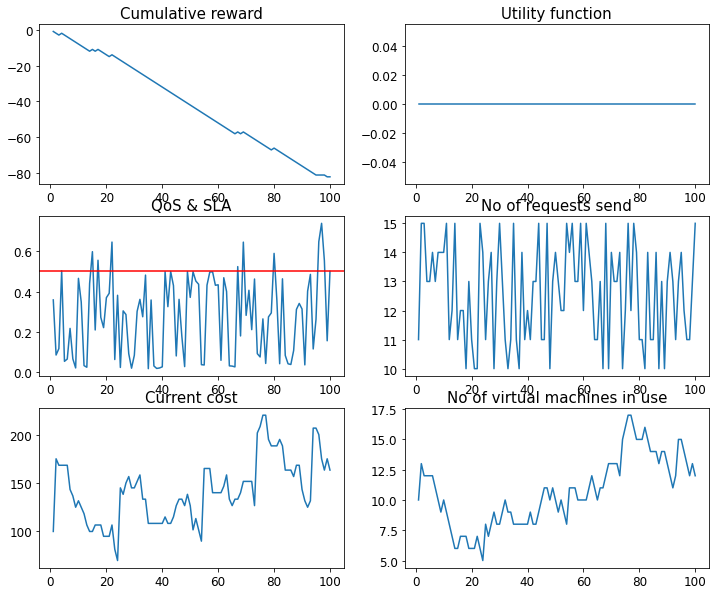

In [15]:
viz_performance(cumulative_reward=value,
               utility_function=utility_function,
               qos=quality_of_service,
               queue_len=queue_len,
               cost = cost_lst,
               no_of_vm = no_of_vm_lst,
               steps=steps_lst,
               sla=SLA)